In [2]:
# ============================================================
# GUARD Connection — 前段AI 前処理パイプライン
# Cell 1: インポート・定数定義
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

# ── パス定数 ──────────────────────────────────────────────────
DATA_ROOT = Path("/kaggle/input/datasets/nagisa2/bidmc-ppg-and-respiration/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv")
OUTPUT_ROOT = Path("/kaggle/working/spectrograms")

# ── 信号定数 ──────────────────────────────────────────────────
FS = 125          # サンプリングレート (Hz)
SEG_SEC = 10      # セグメント長 (秒)
SEG_LEN = FS * SEG_SEC   # = 1250 サンプル
OVERLAP_RATIO = 0.5
HOP_LEN = int(SEG_LEN * (1 - OVERLAP_RATIO))  # = 625 サンプル

# ── スペクトログラム定数（後でパラメータ最適化する） ──────────
NPERSEG = 128     # FFT窓長
NOVERLAP = 96     # オーバーラップ (75%)
IMG_H = 64        # 周波数ビン数（リサイズ後）
IMG_W = 64        # 時間ビン数（リサイズ後）

print(f"SEG_LEN: {SEG_LEN} samples = {SEG_SEC} sec @ {FS} Hz")
print(f"HOP_LEN: {HOP_LEN} samples = {SEG_SEC * OVERLAP_RATIO} sec")
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")

SEG_LEN: 1250 samples = 10 sec @ 125 Hz
HOP_LEN: 625 samples = 5.0 sec
DATA_ROOT exists: True


In [3]:
# ============================================================
# Cell 2: 1被験者分の読み込み・カラム確認
# ============================================================

def load_signals(subject_id: int) -> pd.DataFrame | None:
    """
    bidmc_XX_Signals.csv を読み込み、PPG・ECG列を返す。
    カラム名の先頭スペースをstripし、クリッピング状況を報告する。
    """
    fname = DATA_ROOT / f"bidmc_{subject_id:02d}_Signals.csv"
    if not fname.exists():
        return None

    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip()  # 先頭スペース除去

    # カラム名確認（初回のみ表示）
    return df


# ── 被験者01で構造確認 ────────────────────────────────────────
df_sample = load_signals(1)
print("=== カラム一覧 ===")
print(df_sample.columns.tolist())
print(f"\n=== shape ===")
print(df_sample.shape)
print(f"\n=== 先頭5行 ===")
print(df_sample.head())

=== カラム一覧 ===
['Time [s]', 'RESP', 'PLETH', 'V', 'AVR', 'II']

=== shape ===
(60001, 6)

=== 先頭5行 ===
   Time [s]     RESP    PLETH        V      AVR       II
0     0.000  0.35386  0.43597  0.52549  0.30392  0.72549
1     0.008  0.35679  0.43206  0.51961  0.33529  0.67059
2     0.016  0.35875  0.42815  0.51569  0.37451  0.60980
3     0.024  0.36168  0.42424  0.50588  0.41961  0.55098
4     0.032  0.36364  0.42131  0.50980  0.44902  0.50000


ecg_range: (np.float32(-0.50196), np.float32(1.5039))
ppg_range: (np.float32(0.22385), np.float32(0.69795))
ecg_clip_ratio: 0.025716238062698956
ppg_clip_ratio: 0.00013333111114814753
n_samples: 60001
nan_ecg: 0
nan_ppg: 0


/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 35036 (\N{CJK UNIFIED IDEOGRAPH-88DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/83828619.py:59: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.ti

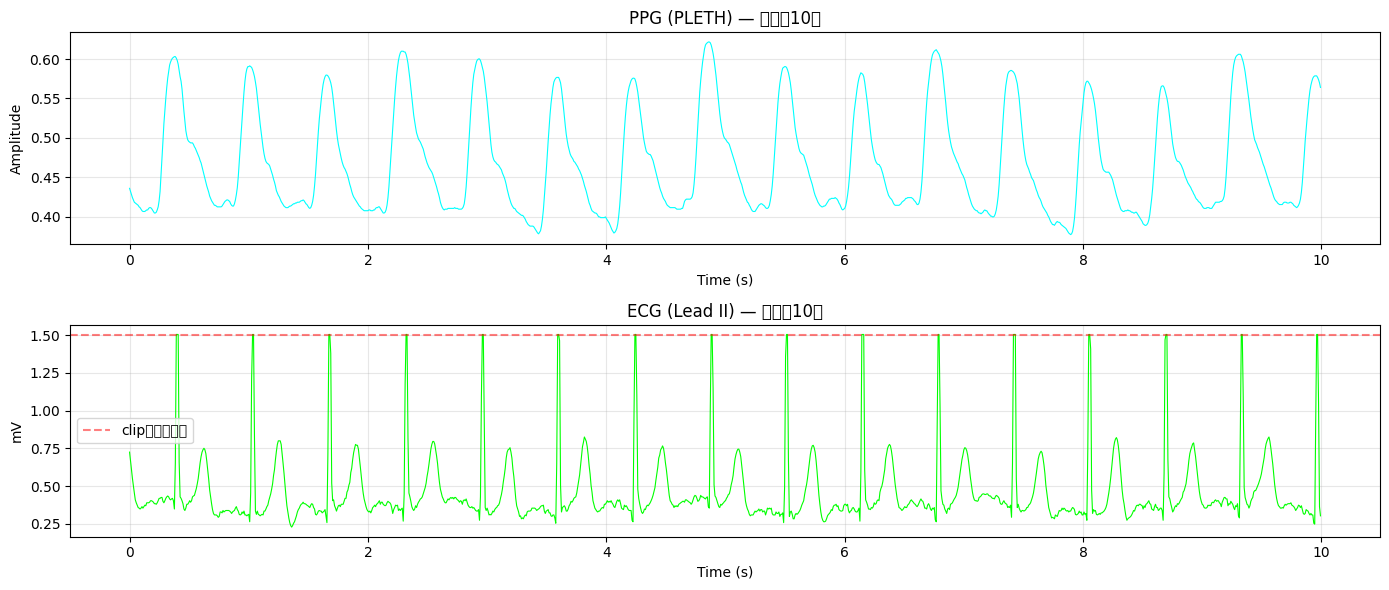

In [4]:
# ============================================================
# Cell 3: クリッピング・信号品質の確認
# ============================================================

def check_signal_quality(df: pd.DataFrame, ppg_col: str, ecg_col: str) -> dict:
    ppg = df[ppg_col].values.astype(np.float32)
    ecg = df[ecg_col].values.astype(np.float32)

    ecg_max = ecg.max()
    ecg_min = ecg.min()
    ppg_max = ppg.max()
    ppg_min = ppg.min()

    # クリッピング検出: 最大値付近に集中しすぎていないか
    clip_threshold = 0.99
    ecg_clip_ratio = (np.abs(ecg) >= ecg_max * clip_threshold).mean()
    ppg_clip_ratio = (np.abs(ppg) >= ppg_max * clip_threshold).mean()

    return {
        "ecg_range": (ecg_min, ecg_max),
        "ppg_range": (ppg_min, ppg_max),
        "ecg_clip_ratio": ecg_clip_ratio,
        "ppg_clip_ratio": ppg_clip_ratio,
        "n_samples": len(ecg),
        "nan_ecg": np.isnan(ecg).sum(),
        "nan_ppg": np.isnan(ppg).sum(),
    }

# ── カラム名は上のセルの確認後に修正すること ──────────────────
# BIDMCの標準的なカラム名（strip後）
PPG_COL = "PLETH"
ECG_COL = "II"

quality = check_signal_quality(df_sample, PPG_COL, ECG_COL)
for k, v in quality.items():
    print(f"{k}: {v}")

# ── 波形プロット（最初の10秒） ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
t = np.arange(SEG_LEN) / FS

ppg_raw = df_sample[PPG_COL].values[:SEG_LEN].astype(np.float32)
ecg_raw = df_sample[ECG_COL].values[:SEG_LEN].astype(np.float32)

ax1.plot(t, ppg_raw, color="cyan", linewidth=0.8)
ax1.set_title("PPG (PLETH) — 最初の10秒")
ax1.set_ylabel("Amplitude")
ax1.set_xlabel("Time (s)")
ax1.grid(alpha=0.3)

ax2.plot(t, ecg_raw, color="lime", linewidth=0.8)
ax2.set_title("ECG (Lead II) — 最初の10秒")
ax2.set_ylabel("mV")
ax2.set_xlabel("Time (s)")
ax2.axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='clip候補ライン')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/signal_check_s01.png", dpi=100)
plt.show()

In [5]:
# ============================================================
# Cell 4: 前処理関数定義
# ============================================================

def bandpass_filter(sig: np.ndarray, fs: int, lowcut: float, highcut: float,
                    order: int = 4) -> np.ndarray:
    """バターワースバンドパスフィルタ"""
    nyq = fs / 2.0
    b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return signal.filtfilt(b, a, sig).astype(np.float32)


def normalize_minmax(sig: np.ndarray) -> np.ndarray:
    """[0, 1] に正規化（スペクトログラム画像生成用）"""
    mn, mx = sig.min(), sig.max()
    if mx - mn < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)
    return ((sig - mn) / (mx - mn)).astype(np.float32)


def preprocess_segment(ppg_seg: np.ndarray, ecg_seg: np.ndarray,
                       fs: int = FS) -> tuple[np.ndarray, np.ndarray]:
    """
    1セグメント分のPPG・ECGを前処理する。
    PPG: 0.5–4 Hz（心拍帯域）
    ECG: 0.5–40 Hz（QRS保持）
    """
    ppg_filtered = bandpass_filter(ppg_seg, fs, lowcut=0.5, highcut=4.0)
    ecg_filtered = bandpass_filter(ecg_seg, fs, lowcut=0.5, highcut=40.0)

    ppg_norm = normalize_minmax(ppg_filtered)
    ecg_norm = normalize_minmax(ecg_filtered)

    return ppg_norm, ecg_norm


# ── 動作確認 ──────────────────────────────────────────────────
ppg_test = df_sample[PPG_COL].values[:SEG_LEN].astype(np.float32)
ecg_test = df_sample[ECG_COL].values[:SEG_LEN].astype(np.float32)

ppg_proc, ecg_proc = preprocess_segment(ppg_test, ecg_test)
print(f"PPG after preprocess: min={ppg_proc.min():.3f}, max={ppg_proc.max():.3f}")
print(f"ECG after preprocess: min={ecg_proc.min():.3f}, max={ecg_proc.max():.3f}")

PPG after preprocess: min=0.000, max=1.000
ECG after preprocess: min=0.000, max=1.000


PPG spectrogram shape: (64, 64), range: [0.000, 0.920]
ECG spectrogram shape: (64, 64), range: [0.000, 0.945]


/tmp/ipykernel_58/3295562103.py:58: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3295562103.py:59: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/spec_check_s01_seg0.png", dpi=100)


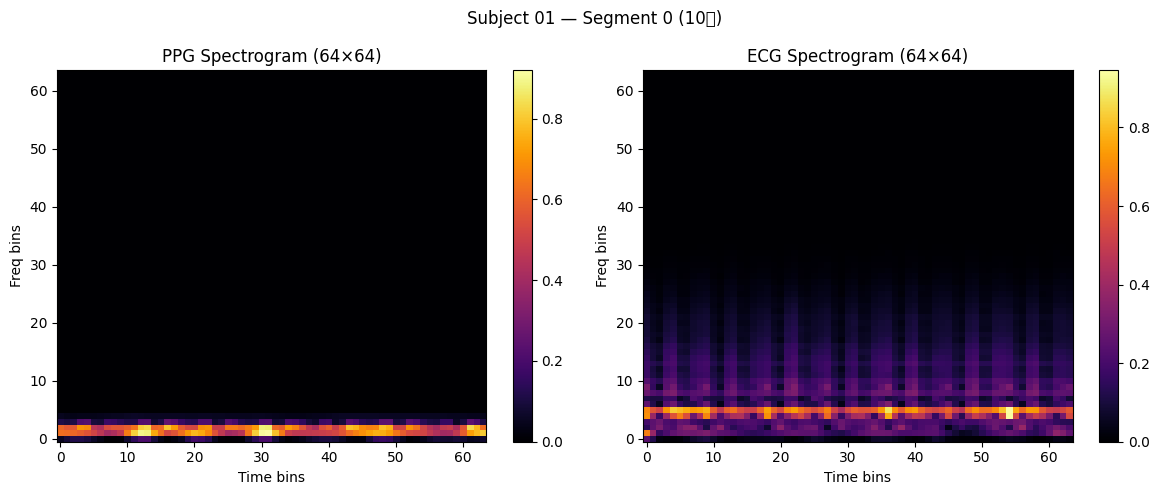

In [6]:
# ============================================================
# Cell 5: スペクトログラム変換・可視化
# ============================================================

from scipy.signal import spectrogram as scipy_spectrogram
from scipy.ndimage import zoom

def signal_to_spectrogram(sig: np.ndarray, fs: int = FS,
                           nperseg: int = NPERSEG,
                           noverlap: int = NOVERLAP,
                           target_h: int = IMG_H,
                           target_w: int = IMG_W) -> np.ndarray:
    """
    1D信号 → 2D スペクトログラム画像 [H, W] (float32, [0,1])
    - log1p スケールで視覚的に均等化
    - 指定サイズにリサイズ
    """
    f, t, Sxx = scipy_spectrogram(sig, fs=fs, nperseg=nperseg,
                                   noverlap=noverlap, window='hann',
                                   scaling='spectrum')

    # 対数スケール変換（数値安定のためlog1p）
    Sxx_log = np.log1p(Sxx).astype(np.float32)

    # [0, 1] 正規化
    Sxx_norm = normalize_minmax(Sxx_log)

    # ターゲットサイズにリサイズ
    zoom_h = target_h / Sxx_norm.shape[0]
    zoom_w = target_w / Sxx_norm.shape[1]
    Sxx_resized = zoom(Sxx_norm, (zoom_h, zoom_w), order=1).astype(np.float32)

    return Sxx_resized


# ── 可視化確認 ────────────────────────────────────────────────
ppg_spec = signal_to_spectrogram(ppg_proc)
ecg_spec = signal_to_spectrogram(ecg_proc)

print(f"PPG spectrogram shape: {ppg_spec.shape}, range: [{ppg_spec.min():.3f}, {ppg_spec.max():.3f}]")
print(f"ECG spectrogram shape: {ecg_spec.shape}, range: [{ecg_spec.min():.3f}, {ecg_spec.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ppg_spec, aspect='auto', origin='lower', cmap='inferno')
axes[0].set_title(f"PPG Spectrogram ({IMG_H}×{IMG_W})")
axes[0].set_xlabel("Time bins")
axes[0].set_ylabel("Freq bins")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(ecg_spec, aspect='auto', origin='lower', cmap='inferno')
axes[1].set_title(f"ECG Spectrogram ({IMG_H}×{IMG_W})")
axes[1].set_xlabel("Time bins")
axes[1].set_ylabel("Freq bins")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.suptitle("Subject 01 — Segment 0 (10秒)")
plt.tight_layout()
plt.savefig("/kaggle/working/spec_check_s01_seg0.png", dpi=100)
plt.show()

In [7]:
# ============================================================
# Cell 6: 全データ処理・保存
# Pix2Pix学習用に (PPG_spec, ECG_spec) ペアとして保存
# ============================================================

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

all_ppg_specs = []
all_ecg_specs = []
all_subject_ids = []
all_segment_ids = []

subject_ids = sorted([
    int(re.search(r'bidmc_(\d+)_Signals', f.name).group(1))
    for f in DATA_ROOT.glob("*_Signals.csv")
])

print(f"処理対象被験者数: {len(subject_ids)}")
print(f"被験者ID一覧: {subject_ids}")

for sid in subject_ids:
    df = load_signals(sid)
    if df is None:
        print(f"  [SKIP] subject {sid:02d}: ファイルなし")
        continue

    ppg_full = df[PPG_COL].values.astype(np.float32)
    ecg_full = df[ECG_COL].values.astype(np.float32)

    n_samples = len(ppg_full)
    seg_count = 0

    start = 0
    while start + SEG_LEN <= n_samples:
        ppg_seg = ppg_full[start:start + SEG_LEN]
        ecg_seg = ecg_full[start:start + SEG_LEN]

        # NaN/Inf チェック（破損セグメントをスキップ）
        if np.isnan(ppg_seg).any() or np.isnan(ecg_seg).any():
            start += HOP_LEN
            continue
        if np.isinf(ppg_seg).any() or np.isinf(ecg_seg).any():
            start += HOP_LEN
            continue

        # 前処理
        ppg_norm, ecg_norm = preprocess_segment(ppg_seg, ecg_seg)

        # スペクトログラム変換
        ppg_spec = signal_to_spectrogram(ppg_norm)
        ecg_spec = signal_to_spectrogram(ecg_norm)

        all_ppg_specs.append(ppg_spec)
        all_ecg_specs.append(ecg_spec)
        all_subject_ids.append(sid)
        all_segment_ids.append(seg_count)

        seg_count += 1
        start += HOP_LEN

    print(f"  Subject {sid:02d}: {seg_count} segments, "
          f"n_samples={n_samples}")

# ── numpy配列に変換して保存 ───────────────────────────────────
ppg_arr = np.stack(all_ppg_specs, axis=0)   # (N, H, W)
ecg_arr = np.stack(all_ecg_specs, axis=0)   # (N, H, W)
subj_arr = np.array(all_subject_ids)
seg_arr  = np.array(all_segment_ids)

print(f"\n=== 保存データ ===")
print(f"PPG specs: {ppg_arr.shape}, dtype={ppg_arr.dtype}")
print(f"ECG specs: {ecg_arr.shape}, dtype={ecg_arr.dtype}")
print(f"Total segments: {len(ppg_arr)}")

np.savez_compressed(
    "/kaggle/working/bidmc_spectrograms.npz",
    ppg=ppg_arr,
    ecg=ecg_arr,
    subject_ids=subj_arr,
    segment_ids=seg_arr,
)
print("\n✓ 保存完了: /kaggle/working/bidmc_spectrograms.npz")

処理対象被験者数: 53
被験者ID一覧: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
  Subject 01: 95 segments, n_samples=60001
  Subject 02: 95 segments, n_samples=60001
  Subject 03: 95 segments, n_samples=60001
  Subject 04: 95 segments, n_samples=60001
  Subject 05: 95 segments, n_samples=60001
  Subject 06: 95 segments, n_samples=60001
  Subject 07: 95 segments, n_samples=60001
  Subject 08: 95 segments, n_samples=60001
  Subject 09: 95 segments, n_samples=60001
  Subject 10: 95 segments, n_samples=60001
  Subject 11: 95 segments, n_samples=60001
  Subject 12: 95 segments, n_samples=60001
  Subject 13: 95 segments, n_samples=60001
  Subject 14: 95 segments, n_samples=60001
  Subject 15: 95 segments, n_samples=60001
  Subject 16: 95 segments, n_samples=60001
  Subject 17: 95 segments, n_samples=60001
  Subject 18: 95 segments, n_samples=60001


In [8]:
# ============================================================
# Cell 7: 保存確認・被験者単位でtrain/val分割
# ============================================================

data = np.load("/kaggle/working/bidmc_spectrograms.npz")
ppg_arr = data["ppg"]
ecg_arr = data["ecg"]
subj_arr = data["subject_ids"]

print(f"ppg shape: {ppg_arr.shape}")
print(f"ecg shape: {ecg_arr.shape}")
print(f"unique subjects: {np.unique(subj_arr)}")
print(f"total segments: {len(ppg_arr)}")

# ── 被験者単位でtrain/val分割（データリーク防止） ────────────
# 注意: セグメント単位で分割すると同一被験者データが
#       train/valに混在してリークが発生する → 必ず被験者単位で分割
unique_subjects = np.unique(subj_arr)
np.random.seed(42)
np.random.shuffle(unique_subjects)

n_val = max(1, int(len(unique_subjects) * 0.2))  # 約20%をval
val_subjects = set(unique_subjects[:n_val])
train_subjects = set(unique_subjects[n_val:])

train_mask = np.array([s in train_subjects for s in subj_arr])
val_mask   = np.array([s in val_subjects   for s in subj_arr])

print(f"\ntrain subjects ({len(train_subjects)}名): "
      f"{sorted(train_subjects)}")
print(f"val subjects ({len(val_subjects)}名): "
      f"{sorted(val_subjects)}")
print(f"train segments: {train_mask.sum()}")
print(f"val segments:   {val_mask.sum()}")

# 分割保存
np.savez_compressed(
    "/kaggle/working/bidmc_train_v2.npz",
    ppg=ppg_arr[train_mask],
    ecg=ecg_arr[train_mask],
    sid=subj_arr[train_mask]
)

np.savez_compressed(
    "/kaggle/working/bidmc_val_v2.npz",
    ppg=ppg_arr[val_mask],
    ecg=ecg_arr[val_mask],
    sid=subj_arr[val_mask]
)

print("\n✓ train/val 分割保存完了")

ppg shape: (5035, 64, 64)
ecg shape: (5035, 64, 64)
unique subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53]
total segments: 5035

train subjects (43名): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(45), np.int64(46), np.int64(47), np.int64(49), np.int64(50), np.int64(52), np.int64(53)]
val subjects (10名): [np.int64(4), np.int64(6), np.int64(13), np.int64(18), np.int64(20), np.int64(33), np.int64(42), np.int64(44

In [9]:
# ============================================================
# Cell 1 修正版 — パラメータ変更
# ============================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import spectrogram as scipy_spectrogram
from scipy.ndimage import zoom
from pathlib import Path

DATA_ROOT   = Path("/kaggle/input/datasets/nagisa2/bidmc-ppg-and-respiration/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv")
OUTPUT_ROOT = Path("/kaggle/working")

FS        = 125
SEG_SEC   = 10
SEG_LEN   = FS * SEG_SEC   # 1250
HOP_LEN   = SEG_LEN // 2   # 625

# ── 修正パラメータ ──────────────────────────────────────────
NPERSEG  = 64    # 窓長を短くして時間分解能を上げる
NOVERLAP = 48    # 75%オーバーラップ
IMG_H    = 64    # 周波数軸（0–62.5Hzを32binに圧縮）
IMG_W    = 128    # 時間軸

PPG_COL = "PLETH"
ECG_COL = "II"

print(f"NPERSEG={NPERSEG} → 周波数分解能: {FS/NPERSEG:.2f} Hz/bin")
print(f"ステップ幅: {NPERSEG - NOVERLAP} samples = {(NPERSEG - NOVERLAP)/FS*1000:.1f} ms")
print(f"10秒セグメントの時間bin数（リサイズ前）: {(SEG_LEN - NOVERLAP) // (NPERSEG - NOVERLAP)}")

NPERSEG=64 → 周波数分解能: 1.95 Hz/bin
ステップ幅: 16 samples = 128.0 ms
10秒セグメントの時間bin数（リサイズ前）: 75


In [ ]:
# ============================================================
# 新規セル: 依存パッケージ・再現性設定
# ============================================================
!pip install neurokit2 librosa -q

import random
import torch
import neurokit2 as nk

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

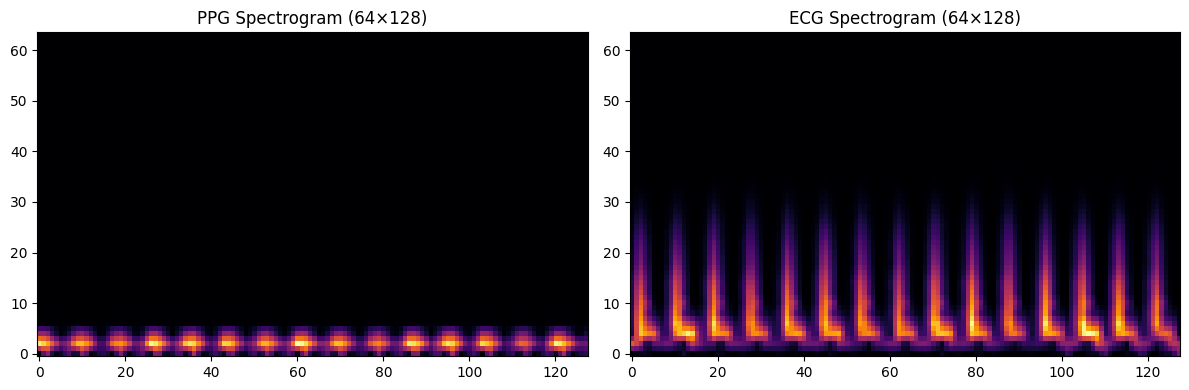

PPG: (5035, 64, 128), ECG: (5035, 64, 128)
train: 4085, val: 950
✓ v2保存完了


In [10]:
# ============================================================
# Cell 2-6 統合版 — 再生成（品質メタデータ・逆変換用統計付き）
# ============================================================

def load_signals(subject_id):
    fname = DATA_ROOT / f"bidmc_{subject_id:02d}_Signals.csv"
    if not fname.exists():
        return None
    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip()
    return df

def bandpass_filter(sig, fs, lowcut, highcut, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return signal.filtfilt(b, a, sig).astype(np.float32)

def normalize_minmax(sig):
    mn, mx = sig.min(), sig.max()
    if mx - mn < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)
    return ((sig - mn) / (mx - mn)).astype(np.float32)

def normalize_zscore(sig):
    mean, std = np.mean(sig), np.std(sig)
    if std < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)
    return ((sig - mean) / std).astype(np.float32)

def preprocess_segment(ppg_seg, ecg_seg, fs=FS):
    ppg_f = bandpass_filter(ppg_seg, fs, 0.5, 4.0)
    ecg_f = bandpass_filter(ecg_seg, fs, 0.5, 40.0)
    ppg_f = normalize_zscore(ppg_f)
    ecg_f = normalize_zscore(ecg_f)
    return ppg_f, ecg_f

def signal_to_spectrogram(sig, fs=FS, return_stats=False):
    f, t, Sxx = scipy_spectrogram(
        sig, fs=fs, nperseg=NPERSEG, noverlap=NOVERLAP,
        window='hann', scaling='spectrum'
    )
    Sxx = np.maximum(Sxx, 1e-12)
    Sxx_log = np.log1p(Sxx)
    log_min, log_max = float(Sxx_log.min()), float(Sxx_log.max())  # ← 逆変換用に保持

    Sxx_norm = normalize_minmax(Sxx_log.astype(np.float32))
    zh = IMG_H / Sxx_norm.shape[0]
    zw = IMG_W / Sxx_norm.shape[1]
    Sxx_resize = zoom(Sxx_norm, (zh, zw), order=1).astype(np.float32)

    if return_stats:
        return Sxx_resize, log_min, log_max
    return Sxx_resize

def segment_quality_metrics(ppg_seg, ecg_seg, fs=FS):
    """クリッピング比率・R波数など、モデル出力と無関係な客観指標のみ算出"""
    ecg_absmax = np.abs(ecg_seg).max()
    ppg_absmax = np.abs(ppg_seg).max()
    ecg_clip = (np.abs(ecg_seg) >= ecg_absmax * 0.99).mean() if ecg_absmax > 0 else 0.0
    ppg_clip = (np.abs(ppg_seg) >= ppg_absmax * 0.99).mean() if ppg_absmax > 0 else 0.0
    try:
        _, info = nk.ecg_peaks(ecg_seg, sampling_rate=fs)
        n_rpeaks = len(info["ECG_R_Peaks"])
    except Exception:
        n_rpeaks = -1  # 検出失敗（フラット/破損の可能性）
    return ecg_clip, ppg_clip, float(ecg_seg.std()), n_rpeaks


# ── 全被験者処理 ──────────────────────────────────────────────
subject_ids = sorted([
    int(re.search(r'bidmc_(\d+)_Signals', f.name).group(1))
    for f in DATA_ROOT.glob("*_Signals.csv")
])

all_ppg, all_ecg, all_sid, all_segid = [], [], [], []
all_ecg_clip, all_ppg_clip, all_ecg_std, all_nrpeaks = [], [], [], []
all_ecg_log_min, all_ecg_log_max = [], []

for sid in subject_ids:
    df = load_signals(sid)
    ppg_full = df[PPG_COL].values.astype(np.float32)
    ecg_full = df[ECG_COL].values.astype(np.float32)
    n = len(ppg_full)
    seg_count, start = 0, 0

    while start + SEG_LEN <= n:
        ppg_seg = ppg_full[start:start+SEG_LEN]
        ecg_seg = ecg_full[start:start+SEG_LEN]

        if np.isnan(ppg_seg).any() or np.isnan(ecg_seg).any():
            start += HOP_LEN; continue

        # ── 品質メタデータ（除外はしない。記録のみ） ──
        ecg_clip, ppg_clip, ecg_std, n_rpeaks = segment_quality_metrics(ppg_seg, ecg_seg)

        ppg_n, ecg_n = preprocess_segment(ppg_seg, ecg_seg)
        ppg_spec = signal_to_spectrogram(ppg_n)
        ecg_spec, ecg_log_min, ecg_log_max = signal_to_spectrogram(ecg_n, return_stats=True)

        all_ppg.append(ppg_spec)
        all_ecg.append(ecg_spec)
        all_sid.append(sid)
        all_segid.append(seg_count)
        all_ecg_clip.append(ecg_clip)
        all_ppg_clip.append(ppg_clip)
        all_ecg_std.append(ecg_std)
        all_nrpeaks.append(n_rpeaks)
        all_ecg_log_min.append(ecg_log_min)
        all_ecg_log_max.append(ecg_log_max)

        seg_count += 1
        start += HOP_LEN

ppg_arr = np.stack(all_ppg)
ecg_arr = np.stack(all_ecg)
subj_arr = np.array(all_sid)
ecg_clip_arr = np.array(all_ecg_clip)
ppg_clip_arr = np.array(all_ppg_clip)
ecg_std_arr  = np.array(all_ecg_std)
nrpeaks_arr  = np.array(all_nrpeaks)
ecg_log_min_arr = np.array(all_ecg_log_min)
ecg_log_max_arr = np.array(all_ecg_log_max)

print(f"PPG: {ppg_arr.shape}, ECG: {ecg_arr.shape}")
print(f"clip>0.05のセグメント数: {(ecg_clip_arr > 0.05).sum()} / {len(ecg_clip_arr)}")
print(f"R波検出失敗(-1)のセグメント数: {(nrpeaks_arr == -1).sum()}")

# ── train/val分割保存（メタデータも同じmaskで分割） ──────────
unique_s = np.unique(subj_arr)
np.random.seed(42)
np.random.shuffle(unique_s)
n_val = max(1, int(len(unique_s) * 0.2))
val_s, train_s = set(unique_s[:n_val]), set(unique_s[n_val:])
train_mask = np.array([s in train_s for s in subj_arr])
val_mask   = np.array([s in val_s   for s in subj_arr])

def save_split(path, mask):
    np.savez_compressed(
        path,
        ppg=ppg_arr[mask], ecg=ecg_arr[mask], sid=subj_arr[mask],
        ecg_clip_ratio=ecg_clip_arr[mask], ppg_clip_ratio=ppg_clip_arr[mask],
        ecg_std=ecg_std_arr[mask], n_rpeaks_raw=nrpeaks_arr[mask],
        ecg_log_min=ecg_log_min_arr[mask], ecg_log_max=ecg_log_max_arr[mask],
    )

save_split("/kaggle/working/bidmc_train_v3.npz", train_mask)
save_split("/kaggle/working/bidmc_val_v3.npz", val_mask)
print(f"train: {train_mask.sum()}, val: {val_mask.sum()}")
print("✓ v3保存完了（品質メタデータ・逆変換統計付き）")

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SpectrogramDataset(Dataset):
    def __init__(self, npz_path):
        data = np.load(npz_path)

        self.ppg = data["ppg"].astype(np.float32)
        self.ecg = data["ecg"].astype(np.float32)

    def __len__(self):
        return len(self.ppg)

    def __getitem__(self, idx):
        ppg = torch.from_numpy(self.ppg[idx]).unsqueeze(0)
        ecg = torch.from_numpy(self.ecg[idx]).unsqueeze(0)

        # Pix2Pix標準の[-1,1]
        ppg = ppg * 2.0 - 1.0
        ecg = ecg * 2.0 - 1.0

        return ppg, ecg

In [12]:
BATCH_SIZE = 32

train_dataset = SpectrogramDataset("/kaggle/working/bidmc_train_v3.npz")
val_dataset   = SpectrogramDataset("/kaggle/working/bidmc_val_v3.npz")

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(len(train_dataset))
print(len(val_dataset))

4085
950


In [13]:
ppg, ecg = next(iter(train_loader))

print(ppg.shape)
print(ecg.shape)

print(ppg.min(), ppg.max())
print(ecg.min(), ecg.max())

torch.Size([32, 1, 64, 128])
torch.Size([32, 1, 64, 128])
tensor(-1.) tensor(0.9827)
tensor(-1.) tensor(0.9896)


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()

        layers = [
            nn.Upsample(
                scale_factor=2,
                mode='bilinear',
                align_corners=False
            ),
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [15]:
import torch
import torch.nn as nn


####################################################
# Encoder
####################################################

class UNetDown(nn.Module):
    def __init__(self,
                 in_size,
                 out_size,
                 normalize=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_size,
                out_size,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            )
        ]

        if normalize:
            layers.append(
                nn.BatchNorm2d(out_size)
            )

        layers.append(
            nn.LeakyReLU(
                0.2,
                inplace=True
            )
        )

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


####################################################
# Decoder Block
####################################################

class UpBlock(nn.Module):
    def __init__(self,
                 in_ch,
                 out_ch,
                 dropout=False):
        super().__init__()

        layers = [
            nn.Upsample(
                scale_factor=2,
                mode='bilinear',
                align_corners=False
            ),
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]

        if dropout:
            layers.append(
                nn.Dropout(0.5)
            )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


####################################################
# Generator
####################################################

class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        ############################
        # Encoder
        ############################

        self.down1 = UNetDown(
            1,
            64,
            normalize=False
        )

        self.down2 = UNetDown(
            64,
            128
        )

        self.down3 = UNetDown(
            128,
            256
        )

        self.down4 = UNetDown(
            256,
            512
        )

        ############################
        # Decoder
        ############################

        self.up1 = UpBlock(
            512,
            256,
            dropout=True
        )

        self.conv1 = nn.Conv2d(
            512,
            256,
            kernel_size=3,
            padding=1
        )

        self.up2 = UpBlock(
            256,
            128,
            dropout=True
        )

        self.conv2 = nn.Conv2d(
            256,
            128,
            kernel_size=3,
            padding=1
        )

        self.up3 = UpBlock(
            128,
            64
        )

        self.conv3 = nn.Conv2d(
            128,
            64,
            kernel_size=3,
            padding=1
        )

        #################################################
        # 追加
        #################################################

        self.up4 = UpBlock(
            64,
            32
        )

        self.final = nn.Sequential(
            nn.Conv2d(
                32,
                1,
                kernel_size=3,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):

        ############################
        # Encoder
        ############################

        d1 = self.down1(x)   # 16×32
        d2 = self.down2(d1)  # 8×16
        d3 = self.down3(d2)  # 4×8
        d4 = self.down4(d3)  # 2×4

        ############################
        # Decoder
        ############################

        u1 = self.up1(d4)
        u1 = torch.cat(
            [u1, d3],
            dim=1
        )
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat(
            [u2, d2],
            dim=1
        )
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat(
            [u3, d1],
            dim=1
        )
        u3 = self.conv3(u3)

        #################################################
        # 16×32 → 32×64
        #################################################

        u4 = self.up4(u3)

        return self.final(u4)

In [16]:
generator = UNetGenerator()

x = torch.randn(
    1,
    1,
    32,
    64
)

y = generator(x)

print(x.shape)
print(y.shape)

torch.Size([1, 1, 32, 64])
torch.Size([1, 1, 32, 64])


In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

generator = UNetGenerator().to(device)

x, y = next(iter(train_loader))

x = x.to(device)

with torch.no_grad():
    pred = generator(x)

print(pred.shape)
print(pred.min(), pred.max())

torch.Size([32, 1, 64, 128])
tensor(-0.9315, device='cuda:0') tensor(0.9857, device='cuda:0')


In [ ]:
# ============================================================
# 新規セル: 学習ループの関数化（λ_L1グリッドサーチ対応）
# ============================================================
from torch.cuda.amp import autocast, GradScaler
from pytorch_msssim import SSIM

def train_pix2pix(train_loader, val_loader, lambda_l1=50, lambda_ssim=10,
                   epochs=50, patience=20, min_delta=0.001,
                   lr_g=2e-4, lr_d=5e-5, save_path=None, seed=42, verbose=True):

    set_seed(seed)

    generator = UNetGenerator().to(device)
    discriminator = PatchDiscriminator().to(device)

    criterion_GAN = nn.BCEWithLogitsLoss()
    criterion_L1 = nn.L1Loss()
    ssim_module = SSIM(data_range=2.0, size_average=True, channel=1)

    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    scaler_G, scaler_D = GradScaler(), GradScaler()

    x0, y0 = next(iter(train_loader))
    with torch.no_grad():
        patch = discriminator(x0.to(device), y0.to(device)).shape[2:]

    history = {"train_g": [], "train_d": [], "val_g": [], "val_d": []}
    best_val, counter = np.inf, 0

    for epoch in range(epochs):
        generator.train(); discriminator.train()
        g_sum = d_sum = 0.0

        for ppg, real_ecg in train_loader:
            ppg, real_ecg = ppg.to(device), real_ecg.to(device)
            bs = ppg.size(0)
            valid = torch.full((bs, 1, *patch), 0.9, device=device)
            fake  = torch.full((bs, 1, *patch), 0.1, device=device)

            optimizer_D.zero_grad()
            with autocast():
                fake_ecg = generator(ppg)
                loss_D = 0.5 * (
                    criterion_GAN(discriminator(ppg, real_ecg), valid) +
                    criterion_GAN(discriminator(ppg, fake_ecg.detach()), fake)
                )
            scaler_D.scale(loss_D).backward()
            scaler_D.step(optimizer_D); scaler_D.update()

            optimizer_G.zero_grad()
            with autocast():
                fake_ecg = generator(ppg)
                loss_GAN = criterion_GAN(discriminator(ppg, fake_ecg), valid)
                loss_L1 = criterion_L1(fake_ecg, real_ecg)
                loss_SSIM = 1.0 - ssim_module(fake_ecg, real_ecg)
                loss_G = loss_GAN + lambda_l1 * loss_L1 + lambda_ssim * loss_SSIM
            scaler_G.scale(loss_G).backward()
            scaler_G.step(optimizer_G); scaler_G.update()

            g_sum += loss_G.item(); d_sum += loss_D.item()

        history["train_g"].append(g_sum / len(train_loader))
        history["train_d"].append(d_sum / len(train_loader))

        generator.eval(); discriminator.eval()
        vg_sum = vd_sum = 0.0
        with torch.no_grad():
            for ppg, real_ecg in val_loader:
                ppg, real_ecg = ppg.to(device), real_ecg.to(device)
                bs = ppg.size(0)
                valid = torch.full((bs, 1, *patch), 0.9, device=device)
                fake  = torch.full((bs, 1, *patch), 0.1, device=device)
                fake_ecg = generator(ppg)
                loss_D_val = 0.5 * (
                    criterion_GAN(discriminator(ppg, real_ecg), valid) +
                    criterion_GAN(discriminator(ppg, fake_ecg), fake)
                )
                loss_GAN = criterion_GAN(discriminator(ppg, fake_ecg), valid)
                loss_L1 = criterion_L1(fake_ecg, real_ecg)
                loss_SSIM = 1.0 - ssim_module(fake_ecg, real_ecg)
                loss_G_val = loss_GAN + lambda_l1 * loss_L1 + lambda_ssim * loss_SSIM
                vg_sum += loss_G_val.item(); vd_sum += loss_D_val.item()

        history["val_g"].append(vg_sum / len(val_loader))
        history["val_d"].append(vd_sum / len(val_loader))

        if history["val_g"][-1] < best_val - min_delta:
            best_val, counter = history["val_g"][-1], 0
            if save_path:
                torch.save(generator.state_dict(), save_path)
        else:
            counter += 1

        if verbose:
            print(f"[λL1={lambda_l1}] Epoch {epoch+1}/{epochs} "
                  f"TrainG={history['train_g'][-1]:.4f} ValG={history['val_g'][-1]:.4f}")

        if counter >= patience:
            print("Early stopping"); break

    return generator, discriminator, history

In [ ]:
# ============================================================
# 新規セル: Step1 — λ_L1スクリーニング（各15epoch）
# ============================================================
lambda_candidates = [50, 20, 10, 5]
screening = {}

for lam in lambda_candidates:
    gen, disc, hist = train_pix2pix(
        train_loader, val_loader,
        lambda_l1=lam, lambda_ssim=10, epochs=15, patience=15,
        save_path=f"/kaggle/working/gen_lambda{lam}_screen.pth",
        verbose=False
    )
    screening[lam] = {"generator": gen, "history": hist}
    print(f"λL1={lam}: TrainG(last)={hist['train_g'][-1]:.4f} "
          f"ValG(last)={hist['val_g'][-1]:.4f}")

plt.figure(figsize=(8,5))
for lam, r in screening.items():
    plt.plot(r["history"]["val_g"], label=f"λL1={lam}")
plt.xlabel("Epoch"); plt.ylabel("Val G Loss"); plt.legend(); plt.grid()
plt.title("λ_L1スクリーニング比較")
plt.savefig("/kaggle/working/lambda_screening.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# 新規セル: 本番学習（screeningで選定したλ_L1を使用）
# ============================================================
BEST_LAMBDA_L1 = 20  # ← screening結果を見て手動で確定させる

generator, discriminator, history = train_pix2pix(
    train_loader, val_loader,
    lambda_l1=BEST_LAMBDA_L1, lambda_ssim=10,
    epochs=50, patience=20,
    save_path="/kaggle/working/best_generator.pth",
    verbose=True
)

generator.load_state_dict(torch.load("/kaggle/working/best_generator.pth"))
generator.eval()

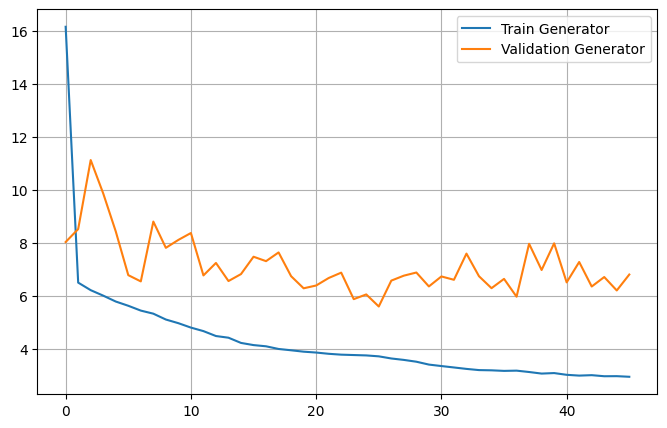

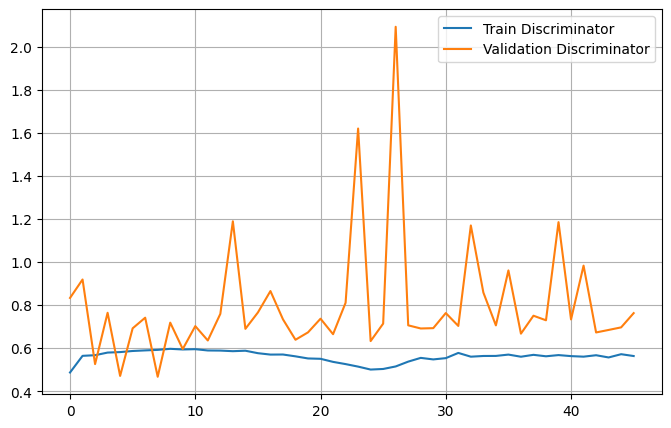

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_g_losses,
    label="Train Generator"
)

plt.plot(
    val_g_losses,
    label="Validation Generator"
)

plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    train_d_losses,
    label="Train Discriminator"
)

plt.plot(
    val_d_losses,
    label="Validation Discriminator"
)

plt.savefig(
    "/kaggle/working/loss_curve.png",
    dpi=300
)

plt.legend()
plt.grid()
plt.show()

In [107]:
torch.save(
    generator.state_dict(),
    "/kaggle/working/pix2pix_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "/kaggle/working/pix2pix_discriminator.pth"
)

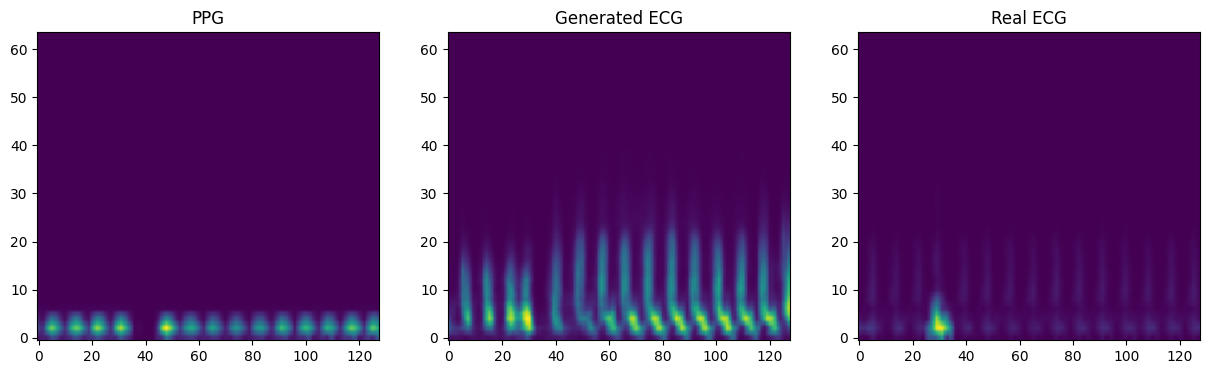

In [108]:
generator.eval()

ppg, real_ecg = next(iter(val_loader))

ppg = ppg.to(device)
real_ecg = real_ecg.to(device)

with torch.no_grad():
    fake_ecg = generator(ppg)

sample = 0

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

ax[0].imshow(
    ppg[sample,0].cpu(),
    aspect="auto",
    origin="lower"
)
ax[0].set_title("PPG")

ax[1].imshow(
    fake_ecg[sample,0].cpu(),
    aspect="auto",
    origin="lower"
)
ax[1].set_title("Generated ECG")

ax[2].imshow(
    real_ecg[sample,0].cpu(),
    aspect="auto",
    origin="lower"
)
ax[2].set_title("Real ECG")

plt.show()

In [109]:
# ============================================================
# 修正: 定量評価（data_range統一版。旧Cell31/38/39を統合）
# ============================================================
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr

DATA_RANGE = 2.0  # データは[-1,1]なので必ず2.0を使用

generator.eval()
mse_list, ssim_list, corr_list = [], [], []
x_test, y_test, pred_test = [], [], []

with torch.no_grad():
    for ppg, real_ecg in val_loader:
        ppg, real_ecg = ppg.to(device), real_ecg.to(device)
        fake_ecg = generator(ppg)

        x_test.append(ppg.cpu().numpy())
        y_test.append(real_ecg.cpu().numpy())
        pred_test.append(fake_ecg.cpu().numpy())

        for i in range(fake_ecg.shape[0]):
            gt = real_ecg[i,0].cpu().numpy()
            pred = fake_ecg[i,0].cpu().numpy()
            mse_list.append(mean_squared_error(gt.flatten(), pred.flatten()))
            ssim_list.append(ssim(gt, pred, data_range=DATA_RANGE))
            corr, _ = pearsonr(gt.flatten(), pred.flatten())
            corr_list.append(corr)

x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
pred_test = np.concatenate(pred_test, axis=0)

print(f"MSE : {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")
print(f"SSIM: {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
print(f"Corr: {np.mean(corr_list):.4f} ± {np.std(corr_list):.4f}")

MSE : 0.03057762171828041
SSIM: 0.8483749790350916
Corr: 0.76104903


In [ ]:
# ============================================================
# 新規セル: Step5 — Griffin-Lim波形復元 + R-peak/RR間隔評価
# ============================================================
import librosa

def get_stft_freq_time_bins(seg_len=SEG_LEN, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP):
    dummy = np.zeros(seg_len)
    f, t, _ = scipy_spectrogram(dummy, fs=fs, nperseg=nperseg, noverlap=noverlap,
                                 window='hann', scaling='spectrum')
    return len(f), len(t)

ORIG_H, ORIG_W = get_stft_freq_time_bins()

def denormalize_spectrogram(spec_resized, log_min, log_max, orig_h=ORIG_H, orig_w=ORIG_W):
    """[-1,1]画像→元のSTFT振幅スケールへの近似逆変換（zoomの非可逆性に留意）"""
    spec01 = np.clip((spec_resized + 1.0) / 2.0, 0.0, 1.0)
    zh, zw = orig_h / spec01.shape[0], orig_w / spec01.shape[1]
    spec_orig = zoom(spec01, (zh, zw), order=1)
    log_mag = spec_orig * (log_max - log_min) + log_min
    return np.maximum(np.expm1(log_mag), 0.0).astype(np.float32)

def spectrogram_to_waveform(mag_spec, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP, n_iter=32):
    hop = nperseg - noverlap
    return librosa.griffinlim(mag_spec, n_iter=n_iter, hop_length=hop,
                               win_length=nperseg, window='hann', length=SEG_LEN)

def evaluate_time_domain(real_wave, fake_wave, fs=FS):
    result = {"n_rpeaks_real": np.nan, "n_rpeaks_fake": np.nan,
              "rpeak_count_diff": np.nan, "rr_mean_diff_ms": np.nan}
    try:
        _, ri = nk.ecg_peaks(real_wave, sampling_rate=fs)
        _, fi = nk.ecg_peaks(fake_wave, sampling_rate=fs)
        rp, fp = ri["ECG_R_Peaks"], fi["ECG_R_Peaks"]
        result["n_rpeaks_real"], result["n_rpeaks_fake"] = len(rp), len(fp)
        result["rpeak_count_diff"] = len(fp) - len(rp)
        if len(rp) > 1 and len(fp) > 1:
            rr_r = np.diff(rp) / fs * 1000
            rr_f = np.diff(fp) / fs * 1000
            result["rr_mean_diff_ms"] = abs(rr_r.mean() - rr_f.mean())
    except Exception as e:
        result["error"] = str(e)
    return result

# ── val全体で評価（real/fake両方を同一Griffin-Lim経路で復元し、
#     GAN由来の誤差とSTFT round-trip誤差を分離する） ──
val_npz_v3 = np.load("/kaggle/working/bidmc_val_v3.npz")
ecg_log_min_val = val_npz_v3["ecg_log_min"]
ecg_log_max_val = val_npz_v3["ecg_log_max"]

time_domain_results = []
generator.eval()
with torch.no_grad():
    for i in range(len(val_dataset)):
        ppg_t = val_dataset[i][0].unsqueeze(0).to(device)
        fake_spec = generator(ppg_t)[0,0].cpu().numpy()
        real_spec = val_dataset[i][1][0].numpy()

        log_min, log_max = ecg_log_min_val[i], ecg_log_max_val[i]
        real_mag = denormalize_spectrogram(real_spec, log_min, log_max)
        fake_mag = denormalize_spectrogram(fake_spec, log_min, log_max)

        real_wave = spectrogram_to_waveform(real_mag)
        fake_wave = spectrogram_to_waveform(fake_mag)

        res = evaluate_time_domain(real_wave, fake_wave)
        res["idx"] = i
        time_domain_results.append(res)

td_df = pd.DataFrame(time_domain_results)
print(td_df[["rpeak_count_diff", "rr_mean_diff_ms"]].describe())
print(f"\nR波検出数差の平均絶対値: {td_df['rpeak_count_diff'].abs().mean():.2f} 拍/10秒窓")
print(f"RR間隔平均誤差: {td_df['rr_mean_diff_ms'].mean():.1f} ms")

In [ ]:
# ============================================================
# 新規セル: エネルギーマスクCorr（背景バイアスの影響を定量化）
# ============================================================
def energy_masked_corr(real, fake, top_pct=0.2):
    threshold = np.percentile(real, 100 * (1 - top_pct))
    mask = real >= threshold
    if mask.sum() < 2:
        return np.nan
    return np.corrcoef(real[mask], fake[mask])[0, 1]

masked_corr_list = [
    energy_masked_corr(y_test[i,0], pred_test[i,0])
    for i in range(len(y_test))
]

print(f"全ピクセルCorr     : {np.mean(corr_list):.4f} ± {np.std(corr_list):.4f}")
print(f"エネルギー上位20%Corr: {np.nanmean(masked_corr_list):.4f} ± {np.nanstd(masked_corr_list):.4f}")
print(f"差分（背景バイアスの目安）: {np.mean(corr_list) - np.nanmean(masked_corr_list):.4f}")

In [ ]:
# ============================================================
# 新規セル: Step2 — Worst症例の生波形・R波数・クリッピング確認
# ============================================================
val_npz = np.load("/kaggle/working/bidmc_val_v3.npz")
test_subject_ids = val_npz["sid"]
ecg_clip_val = val_npz["ecg_clip_ratio"]
n_rpeaks_val = val_npz["n_rpeaks_raw"]

worst_idx = np.argsort(corr_list)[:10]

print(f"{'idx':>5} {'subject':>8} {'corr':>7} {'clip':>7} {'n_rpeaks':>9} {'判定':>10}")
for idx in worst_idx:
    clip = ecg_clip_val[idx]
    nrp = n_rpeaks_val[idx]
    if clip > 0.05:
        judge = "クリップ"
    elif nrp == -1 or nrp < 6 or nrp > 22:
        judge = "R波数異常"
    else:
        judge = "原因不明"
    print(f"{idx:>5} {test_subject_ids[idx]:>8} {corr_list[idx]:>7.3f} "
          f"{clip:>7.3f} {nrp:>9} {judge:>10}")

In [ ]:
# ============================================================
# 新規セル: Step3 — 客観的品質フィルタで再学習用データセット作成
# 実行条件: Step2でクリッピング/ノイズが支配的だった場合のみ
# ============================================================
def build_quality_mask(npz_path):
    d = np.load(npz_path)
    clip = d["ecg_clip_ratio"]
    nrp = d["n_rpeaks_raw"]
    std = d["ecg_std"]
    std_thresh = np.percentile(std, 10)  # 下位10%を低振幅ノイズとみなす

    mask = (clip <= 0.05) & (std >= std_thresh)
    # R波数異常（AF疑い含む）は除外せず、フラグとして残す
    flag_arrhythmia_suspect = (nrp != -1) & ((nrp < 6) | (nrp > 22))

    return mask, flag_arrhythmia_suspect

for split in ["train", "val"]:
    path = f"/kaggle/working/bidmc_{split}_v3.npz"
    d = np.load(path)
    mask, af_flag = build_quality_mask(path)

    print(f"{split}: 全{len(mask)} → クリップ/ノイズ除外後{mask.sum()}, "
          f"AF疑いフラグ{af_flag.sum()}件（除外せず保持）")

    np.savez_compressed(
        f"/kaggle/working/bidmc_{split}_v4.npz",
        ppg=d["ppg"][mask], ecg=d["ecg"][mask], sid=d["sid"][mask],
        ecg_clip_ratio=d["ecg_clip_ratio"][mask],
        n_rpeaks_raw=d["n_rpeaks_raw"][mask],
        ecg_log_min=d["ecg_log_min"][mask], ecg_log_max=d["ecg_log_max"][mask],
        arrhythmia_suspect_flag=af_flag[mask],
    )

In [110]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/working/pix2pix_generator.pth
/kaggle/working/bidmc_train_v2.npz
/kaggle/working/generator_final.pth
/kaggle/working/bidmc_spectrograms.npz
/kaggle/working/signal_check_s01.png
/kaggle/working/result.txt
/kaggle/working/bidmc_train_v3.npz
/kaggle/working/bidmc_val_v2.npz
/kaggle/working/val_g.npy
/kaggle/working/pix2pix_discriminator.pth
/kaggle/working/best_generator.pth
/kaggle/working/spec_v2_check.png
/kaggle/working/bidmc_val_v3.npz
/kaggle/working/sample_21.png
/kaggle/working/bidmc_val.npz
/kaggle/working/loss_curve.png
/kaggle/working/train_g.npy
/kaggle/working/bidmc_train.npz
/kaggle/working/spec_check_s01_seg0.png
/kaggle/working/discriminator_final.pth
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/inference/sample_14.png
/kaggle/working/inference/sample_18.png
/kaggle/working/inference/sample_06.png
/kaggle/working/inference/sample_12.png
/kaggle/working/inference/sample_15.png
/kaggle/working/inference/sample_01.png
/kaggle/working/in

In [111]:
torch.save(
    generator.state_dict(),
    "/kaggle/working/generator_final.pth"
)

torch.save(
    discriminator.state_dict(),
    "/kaggle/working/discriminator_final.pth"
)

print("Model saved.")

Model saved.


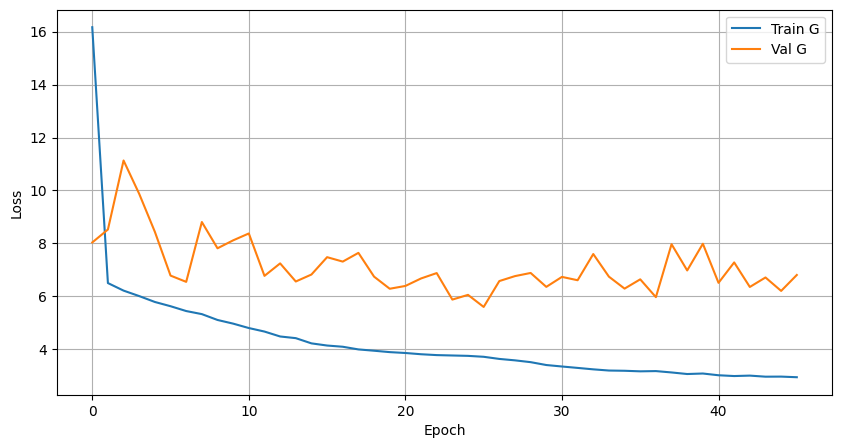

In [112]:
plt.figure(figsize=(10,5))

plt.plot(
    train_g_losses,
    label="Train G"
)

plt.plot(
    val_g_losses,
    label="Val G"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.savefig(
    "/kaggle/working/loss_curve.png",
    dpi=300
)

plt.show()

In [113]:
generator.eval()

save_dir = "/kaggle/working/inference"
os.makedirs(save_dir, exist_ok=True)

In [114]:
with torch.no_grad():

    for i in range(30):

        ppg = val_dataset[i][0].unsqueeze(0).to(device)
        real = val_dataset[i][1].unsqueeze(0).to(device)

        fake = generator(ppg)

        fig, ax = plt.subplots(
            1,
            3,
            figsize=(12,4)
        )

        ax[0].imshow(
            ppg[0,0].cpu(),
            origin="lower",
            aspect="auto",
            cmap="inferno"
        )
        ax[0].set_title("PPG")

        ax[1].imshow(
            real[0,0].cpu(),
            origin="lower",
            aspect="auto",
            cmap="inferno"
        )
        ax[1].set_title("Real ECG")

        ax[2].imshow(
            fake[0,0].cpu(),
            origin="lower",
            aspect="auto",
            cmap="inferno"
        )
        ax[2].set_title("Generated ECG")

        plt.tight_layout()

        plt.savefig(
            f"{save_dir}/sample_{i:02d}.png"
        )

        plt.close()

In [115]:
from skimage.metrics import structural_similarity as ssim

print(type(ssim))

<class 'function'>


In [116]:
mse_list = []
ssim_list = []
corr_list = []

generator.eval()

with torch.no_grad():

    for ppg, real in val_loader:

        ppg = ppg.to(device)
        real = real.to(device)

        fake = generator(ppg)

        fake_np = fake.cpu().numpy()
        real_np = real.cpu().numpy()

        for i in range(fake_np.shape[0]):

            f = fake_np[i,0]
            r = real_np[i,0]

            mse_list.append(
                np.mean((f-r)**2)
            )

            ssim_list.append(
                ssim(
                    r,
                    f,
                    data_range=1.0
                )
            )

            corr_list.append(
                np.corrcoef(
                    r.flatten(),
                    f.flatten()
                )[0,1]
            )

In [117]:
print("MSE")
print(
    np.mean(mse_list),
    "±",
    np.std(mse_list)
)

print("SSIM")
print(
    np.mean(ssim_list),
    "±",
    np.std(ssim_list)
)

print("Corr")
print(
    np.mean(corr_list),
    "±",
    np.std(corr_list)
)

MSE
0.030577622 ± 0.01571065
SSIM
0.8149164073497973 ± 0.09344785184432809
Corr
0.7610489837484958 ± 0.15478969203215157


In [118]:
x_test = []
y_test = []
pred_test = []

generator.eval()

with torch.no_grad():

    for ppg, real_ecg in val_loader:

        ppg = ppg.to(device)
        real_ecg = real_ecg.to(device)

        fake_ecg = generator(ppg)

        x_test.append(
            ppg.cpu().numpy()
        )

        y_test.append(
            real_ecg.cpu().numpy()
        )

        pred_test.append(
            fake_ecg.cpu().numpy()
        )

x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
pred_test = np.concatenate(pred_test, axis=0)

print(x_test.shape)
print(y_test.shape)
print(pred_test.shape)
print("test_subject_ids" in globals())

(950, 1, 64, 128)
(950, 1, 64, 128)
(950, 1, 64, 128)
False


In [119]:
corr_arr = np.array(corr_list)

worst_idx = np.argsort(corr_arr)[:10]

print(worst_idx)
print(corr_arr[worst_idx])

[475 520 514 722 535 530   2 485 536  81]
[0.2358907  0.2671041  0.28360739 0.30149719 0.32418983 0.32496555
 0.32668671 0.33377216 0.3376775  0.33841365]


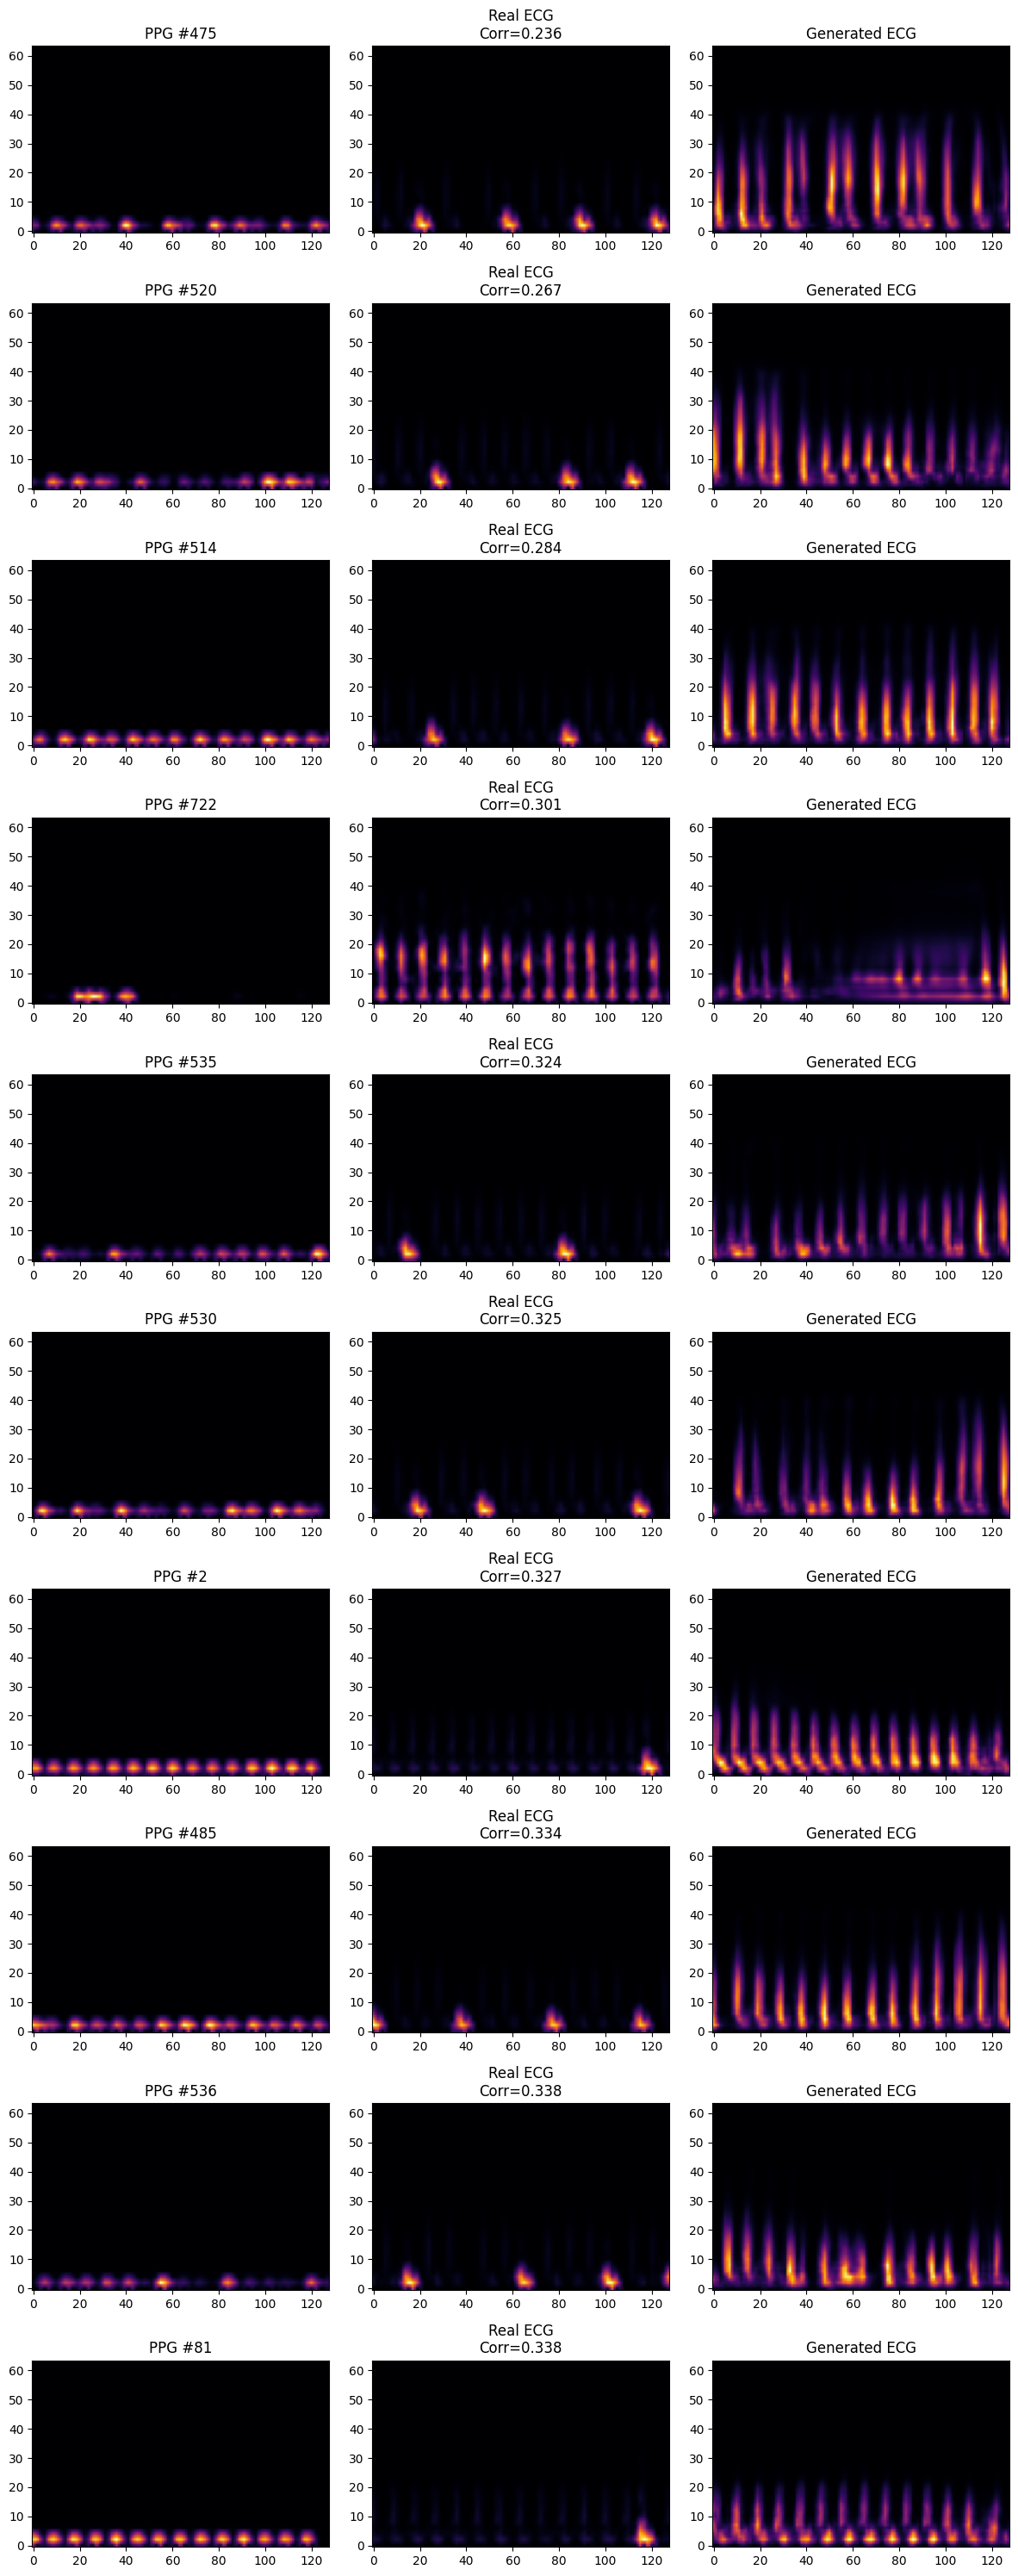

In [121]:
worst_idx = np.argsort(corr_list)[:10]

fig, axes = plt.subplots(
    len(worst_idx),
    3,
    figsize=(12, 3*len(worst_idx))
)

for i, idx in enumerate(worst_idx):

    ppg = x_test[idx,0]
    real = y_test[idx,0]
    fake = pred_test[idx,0]

    axes[i,0].imshow(
        ppg,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,0].set_title(f"PPG #{idx}")

    axes[i,1].imshow(
        real,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,1].set_title(
        f"Real ECG\nCorr={corr_list[idx]:.3f}"
    )

    axes[i,2].imshow(
        fake,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,2].set_title("Generated ECG")

plt.tight_layout()
plt.show()

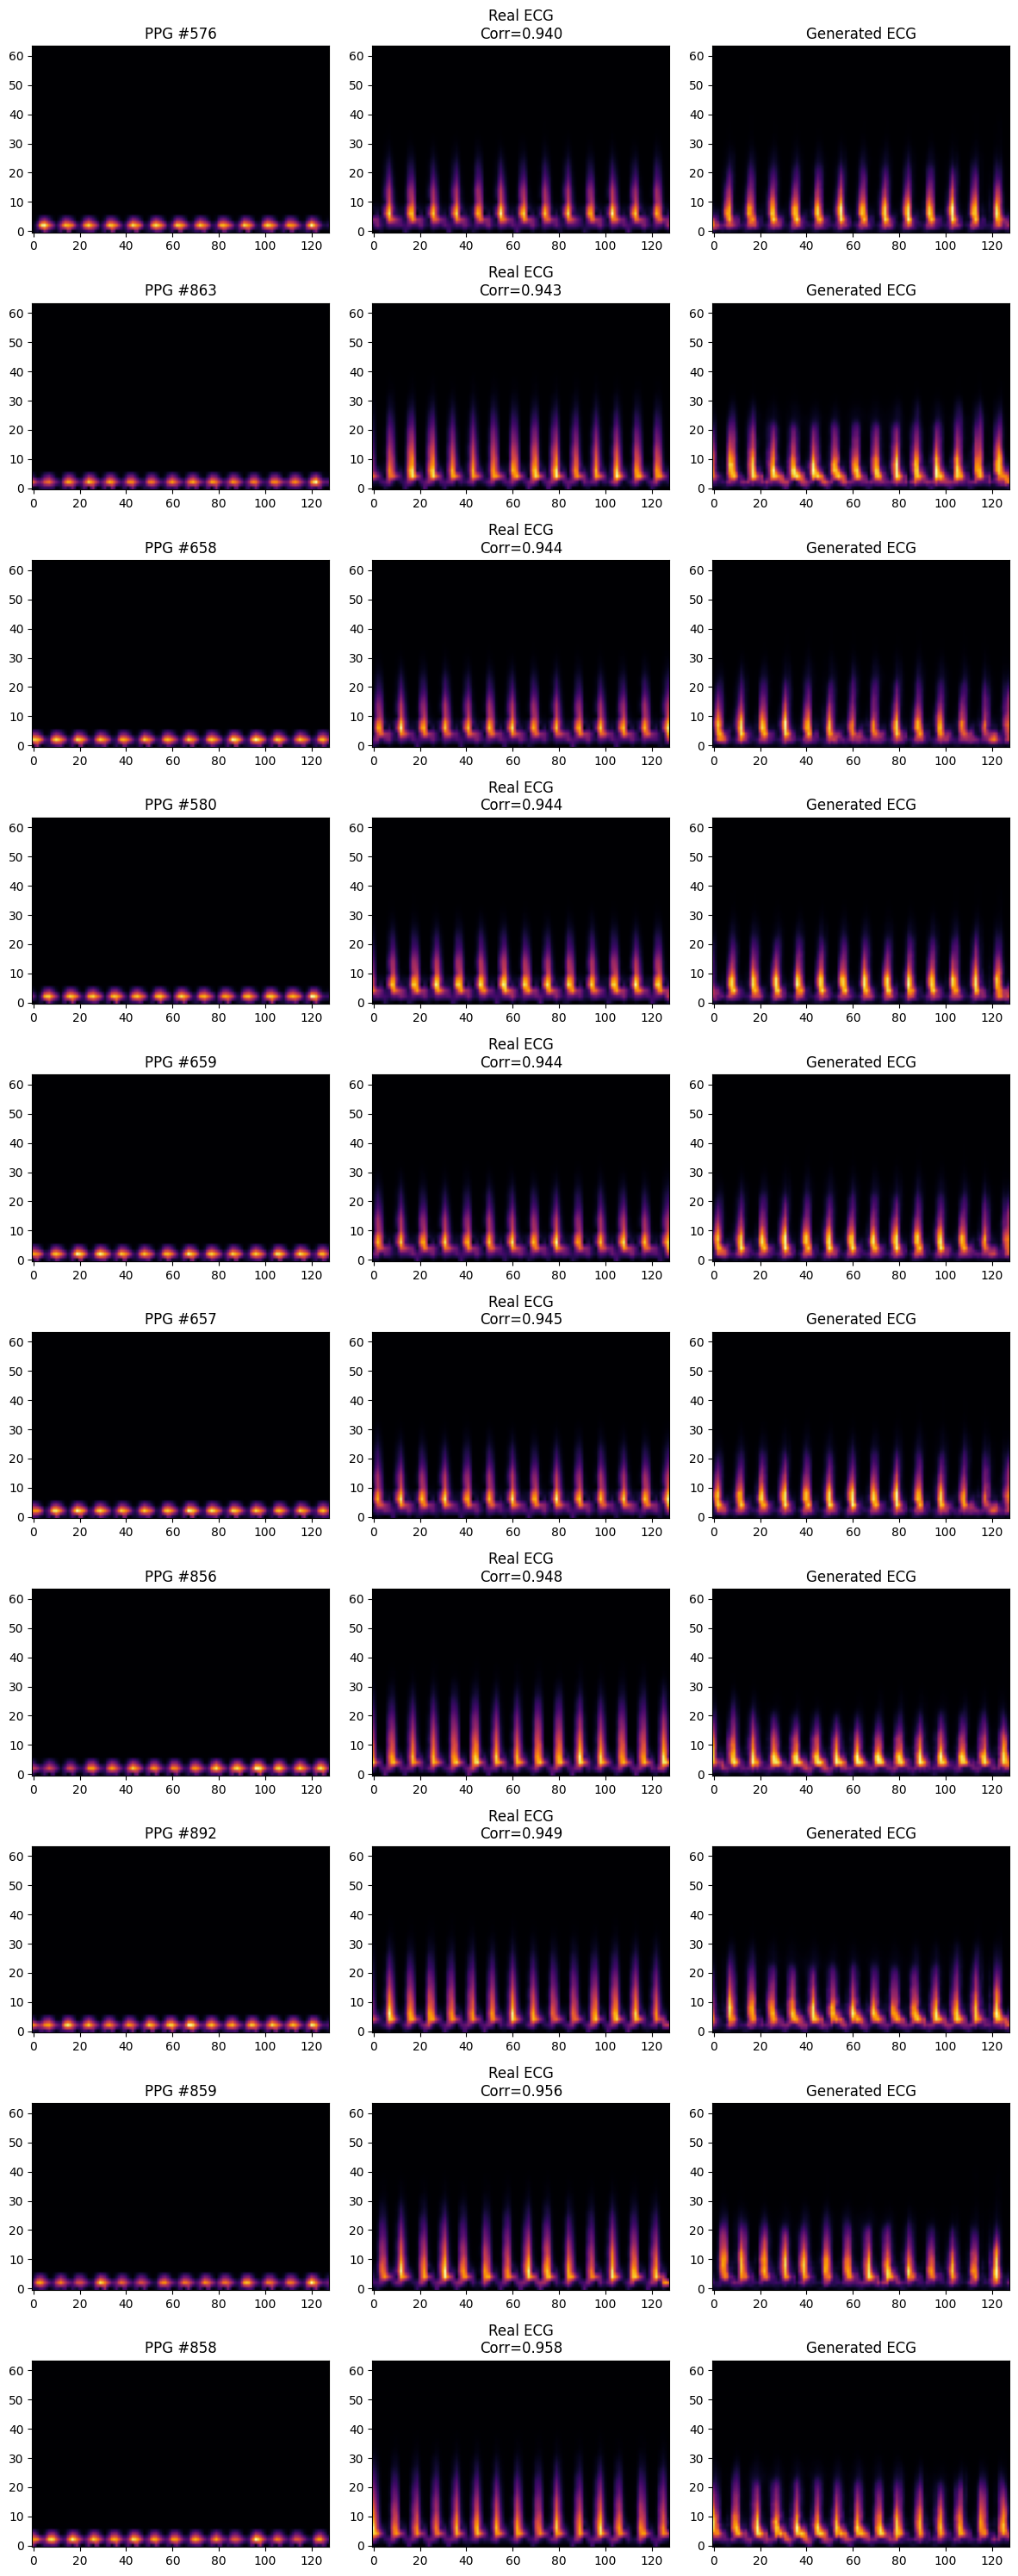

In [122]:
best_idx = np.argsort(corr_list)[-10:]

fig, axes = plt.subplots(
    len(best_idx),
    3,
    figsize=(12, 3*len(best_idx))
)

for i, idx in enumerate(best_idx):

    ppg = x_test[idx,0]
    real = y_test[idx,0]
    fake = pred_test[idx,0]

    axes[i,0].imshow(
        ppg,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,0].set_title(f"PPG #{idx}")

    axes[i,1].imshow(
        real,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,1].set_title(
        f"Real ECG\nCorr={corr_list[idx]:.3f}"
    )

    axes[i,2].imshow(
        fake,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,2].set_title("Generated ECG")

plt.tight_layout()
plt.show()

In [1]:
plt.figure(figsize=(7,5))

plt.hist(
    corr_list,
    bins=30
)

plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title("Distribution of Correlation")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
val_npz = np.load(
    "/kaggle/working/bidmc_val_v3.npz"
)

test_subject_ids = val_npz["sid"]

In [ ]:
subject_corr = {}

for sid, c in zip(test_subject_ids, corr_list):

    if sid not in subject_corr:
        subject_corr[sid] = []

    subject_corr[sid].append(c)

for sid in sorted(subject_corr):

    arr = np.array(subject_corr[sid])

    print(
        f"Subject {sid:02d} : "
        f"{arr.mean():.3f} ± {arr.std():.3f}"
    )